# Noise Models

This notebook compares three additive Gaussian noise models applied to the same deterministic reference signal:

1. **Conventional AWGN**, whose PSD is ideally flat and whose variance is constant in time.
2. **Gaussian-bell PSD noise**, whose PSD is concentrated around 0 Hz according to a Gaussian spectral envelope.
3. **Gaussian-variance AWGN**, interpreted here as independent Gaussian samples whose **time-varying variance** follows a Gaussian bell over the sample index.

The reusable implementations live in `common/`; this notebook stays thin and only orchestrates the comparison.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch

repo_root = Path.cwd().resolve()
if not (repo_root / "common").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.awgn import awgn
from common.gaussian_bell_noise import gaussian_bell_noise
from common.gaussian_bell_noise import gaussian_variance_awgn


def estimate_welch_psd(
    x_t: np.ndarray,
    sample_rate_hz: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate a one-sided PSD with Welch's averaged method."""
    centered_signal = np.asarray(x_t, dtype=np.float64) - np.mean(x_t, dtype=np.float64)
    nperseg = min(256, centered_signal.size)
    frequency_hz, psd = welch(
        centered_signal,
        fs=sample_rate_hz,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend=False,
        scaling="density",
    )
    return frequency_hz, psd


def estimate_sample_acf(
    x_t: np.ndarray,
    max_lag_samples: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate the normalized sample autocorrelation up to ``max_lag_samples``."""
    centered_signal = np.asarray(x_t, dtype=np.float64) - np.mean(x_t, dtype=np.float64)
    correlation = np.correlate(centered_signal, centered_signal, mode="full")
    zero_lag_index = centered_signal.size - 1
    positive_lags = correlation[zero_lag_index : zero_lag_index + max_lag_samples + 1]
    if positive_lags[0] <= 0.0:
        raise RuntimeError("Sample autocorrelation is undefined for a zero-variance record.")
    lag_samples = np.arange(max_lag_samples + 1, dtype=np.int64)
    return lag_samples, positive_lags / positive_lags[0]


def gaussian_pdf_1d(
    x: np.ndarray,
    mean: float,
    variance: float,
) -> np.ndarray:
    """Evaluate a 1-D Gaussian density with variance regularization."""
    safe_variance = max(float(variance), 1e-12)
    normalized_distance = (np.asarray(x, dtype=np.float64) - mean) ** 2 / safe_variance
    return np.exp(-0.5 * normalized_distance) / np.sqrt(2.0 * np.pi * safe_variance)


def weighted_quantile_points(
    x: np.ndarray,
    sample_weights: np.ndarray,
    num_points: int,
) -> np.ndarray:
    """Choose deterministic initialization points from weighted quantiles."""
    cumulative_weights = np.cumsum(sample_weights)
    quantiles = np.linspace(0.1, 0.9, num_points)
    return np.interp(quantiles, cumulative_weights, x)


def fit_weighted_gaussian_mixture_1d(
    x: np.ndarray,
    sample_weights: np.ndarray,
    num_components: int = 4,
    max_iterations: int = 250,
    tolerance: float = 1e-9,
    regularization_var: float = 1e-4,
) -> dict[str, np.ndarray | float]:
    """Fit a 1-D Gaussian mixture to weighted samples using EM.

    Here the Welch PSD values play the role of non-negative sample weights,
    so the fitted mixture reconstructs the spectral envelope rather than a
    time-domain sample distribution.
    """
    frequency_hz = np.asarray(x, dtype=np.float64)
    weights = np.maximum(np.asarray(sample_weights, dtype=np.float64), 0.0)

    if frequency_hz.ndim != 1 or weights.ndim != 1 or frequency_hz.size != weights.size:
        raise ValueError("x and sample_weights must be 1-D arrays with the same length.")
    if num_components < 1:
        raise ValueError("num_components must be >= 1.")

    total_weight = float(np.sum(weights))
    if total_weight <= 0.0:
        raise ValueError("sample_weights must contain positive mass.")

    normalized_weights = weights / total_weight
    means_hz = weighted_quantile_points(frequency_hz, normalized_weights, num_components)

    weighted_mean_hz = float(np.sum(normalized_weights * frequency_hz))
    global_variance_hz2 = float(
        np.sum(normalized_weights * (frequency_hz - weighted_mean_hz) ** 2)
    )
    variances_hz2 = np.full(
        num_components,
        max(global_variance_hz2 / max(num_components, 1), regularization_var),
        dtype=np.float64,
    )
    mixing_weights = np.full(num_components, 1.0 / num_components, dtype=np.float64)
    previous_log_likelihood = -np.inf

    # Alternate between soft assignments and weighted moment updates.
    for _ in range(max_iterations):
        log_component_density = []
        for component_index in range(num_components):
            component_pdf = gaussian_pdf_1d(
                frequency_hz,
                mean=means_hz[component_index],
                variance=variances_hz2[component_index],
            )
            log_component_density.append(
                np.log(np.maximum(mixing_weights[component_index], 1e-300))
                + np.log(np.maximum(component_pdf, 1e-300))
            )
        log_component_density = np.column_stack(log_component_density)

        max_log_density = np.max(log_component_density, axis=1, keepdims=True)
        stabilized_density = np.exp(log_component_density - max_log_density)
        density_normalizer = np.sum(stabilized_density, axis=1, keepdims=True)
        responsibilities = stabilized_density / np.maximum(density_normalizer, 1e-300)

        component_mass = np.sum(normalized_weights[:, None] * responsibilities, axis=0)
        component_mass = np.maximum(component_mass, 1e-12)
        mixing_weights = component_mass / np.sum(component_mass)

        means_hz = (
            np.sum(normalized_weights[:, None] * responsibilities * frequency_hz[:, None], axis=0)
            / component_mass
        )
        variances_hz2 = (
            np.sum(
                normalized_weights[:, None]
                * responsibilities
                * (frequency_hz[:, None] - means_hz[None, :]) ** 2,
                axis=0,
            )
            / component_mass
        )
        variances_hz2 = np.maximum(variances_hz2, regularization_var)

        log_likelihood = float(
            np.sum(
                normalized_weights
                * (
                    max_log_density[:, 0]
                    + np.log(np.maximum(density_normalizer[:, 0], 1e-300))
                )
            )
        )
        if abs(log_likelihood - previous_log_likelihood) < tolerance:
            break
        previous_log_likelihood = log_likelihood

    sorted_index = np.argsort(means_hz)
    return {
        "mixing_weights": mixing_weights[sorted_index],
        "means_hz": means_hz[sorted_index],
        "variances_hz2": variances_hz2[sorted_index],
        "log_likelihood": previous_log_likelihood,
    }


def evaluate_gaussian_mixture_1d(
    x: np.ndarray,
    mixing_weights: np.ndarray,
    means_hz: np.ndarray,
    variances_hz2: np.ndarray,
) -> np.ndarray:
    """Evaluate a 1-D Gaussian-mixture density on the frequency grid."""
    component_densities = []
    for weight, mean_hz, variance_hz2 in zip(
        mixing_weights, means_hz, variances_hz2, strict=True
    ):
        component_densities.append(weight * gaussian_pdf_1d(x, mean_hz, variance_hz2))
    return np.sum(component_densities, axis=0)


def reconstruct_psd_with_gmm(
    frequency_hz: np.ndarray,
    psd: np.ndarray,
    num_components: int = 4,
) -> dict[str, np.ndarray | float]:
    """Fit a GMM to a Welch PSD and rescale it back to PSD units."""
    fit = fit_weighted_gaussian_mixture_1d(
        x=frequency_hz,
        sample_weights=psd,
        num_components=num_components,
    )
    mixture_density = evaluate_gaussian_mixture_1d(
        x=frequency_hz,
        mixing_weights=fit["mixing_weights"],
        means_hz=fit["means_hz"],
        variances_hz2=fit["variances_hz2"],
    )

    # Match the integrated spectral power so the reconstruction remains in PSD units.
    original_power = float(np.trapezoid(psd, x=frequency_hz))
    reconstructed_power = float(np.trapezoid(mixture_density, x=frequency_hz))
    scaling = original_power / max(reconstructed_power, 1e-12)
    reconstructed_psd = scaling * mixture_density
    rmse = float(np.sqrt(np.mean((reconstructed_psd - psd) ** 2)))

    return {
        **fit,
        "reconstructed_psd": reconstructed_psd,
        "rmse": rmse,
    }


In [18]:
sample_rate_hz = 200.0
duration_s = 4.0
num_samples = int(sample_rate_hz * duration_s)
time_s = np.arange(num_samples, dtype=np.float64) / sample_rate_hz
max_lag_samples = 80

# Use a deterministic reference signal so only the noise model changes.
reference_signal = (
    np.sin(2.0 * np.pi * 3.0 * time_s)
    + 0.35 * np.sin(2.0 * np.pi * 15.0 * time_s)
)

snr_db = 12.0
signal_power = float(np.mean(reference_signal**2, dtype=np.float64))
target_noise_std = float(np.sqrt(signal_power / (10.0 ** (snr_db / 10.0))))

gmm_components = 1
spectral_std_hz = 4.0
profile_std_samples = 0.18 * num_samples
center_sample = 0.5 * (num_samples - 1)

awgn_noise = awgn(
    x_t=reference_signal,
    snr_db=snr_db,
    rng=np.random.default_rng(1),
    preserve_dtype=False,
) - reference_signal

gaussian_psd_noise = gaussian_bell_noise(
    num_samples=num_samples,
    sample_rate_hz=sample_rate_hz,
    target_std=target_noise_std,
    spectral_std_hz=spectral_std_hz,
    rng=np.random.default_rng(2),
)

gaussian_variance_noise = gaussian_variance_awgn(
    num_samples=num_samples,
    target_std=target_noise_std,
    profile_std_samples=profile_std_samples,
    center_sample=center_sample,
    rng=np.random.default_rng(3),
)

noise_models = [
    ("AWGN", awgn_noise),
    ("Gaussian-bell PSD", gaussian_psd_noise),
    ("Gaussian-variance AWGN", gaussian_variance_noise),
]


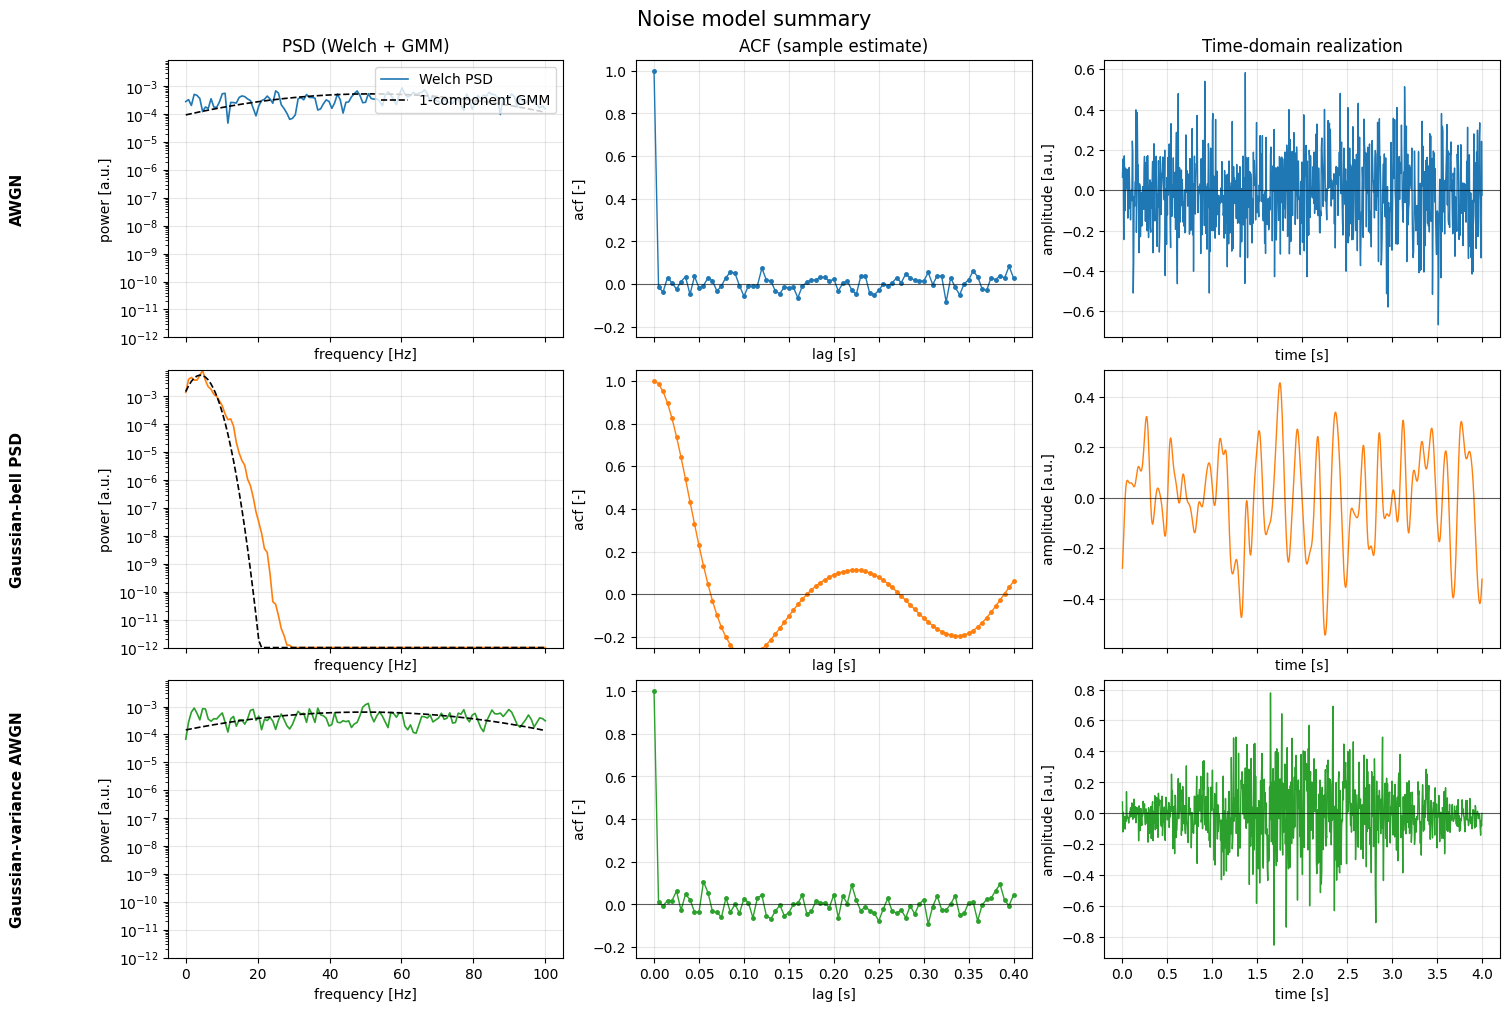

num_samples = 800
target_noise_std = 0.1882
AWGN: empirical std = 0.1850
Gaussian-bell PSD: empirical std = 0.1882
Gaussian-variance AWGN: empirical std = 0.1882


In [19]:
figure, axes = plt.subplots(3, 3, figsize=(15, 10), sharex="col", constrained_layout=True)
column_titles = ["PSD (Welch + GMM)", "ACF (sample estimate)", "Time-domain realization"]
row_colors = ["tab:blue", "tab:orange", "tab:green"]

for column_index, title in enumerate(column_titles):
    axes[0, column_index].set_title(title)

plot_rows = []
for (model_name, noise_t), color in zip(noise_models, row_colors, strict=True):
    frequency_hz, psd = estimate_welch_psd(noise_t, sample_rate_hz=sample_rate_hz)
    lag_samples, acf = estimate_sample_acf(noise_t, max_lag_samples=max_lag_samples)
    reconstruction = reconstruct_psd_with_gmm(
        frequency_hz=frequency_hz,
        psd=psd,
        num_components=gmm_components,
    )
    plot_rows.append(
        {
            "model_name": model_name,
            "noise_t": noise_t,
            "color": color,
            "frequency_hz": frequency_hz,
            "psd": np.maximum(psd, 1e-12),
            "reconstructed_psd": np.maximum(reconstruction["reconstructed_psd"], 1e-12),
            "lag_samples": lag_samples,
            "acf": acf,
        }
    )

global_psd_min = min(
    float(np.min(np.minimum(row["psd"], row["reconstructed_psd"])))
    for row in plot_rows
)
global_psd_max = max(
    float(np.max(np.maximum(row["psd"], row["reconstructed_psd"])))
    for row in plot_rows
)
global_psd_max = max(global_psd_max, global_psd_min * 10.0)

for row_index, row in enumerate(plot_rows):
    axes[row_index, 0].semilogy(
        row["frequency_hz"],
        row["psd"],
        color=row["color"],
        linewidth=1.2,
        label="Welch PSD" if row_index == 0 else None,
    )
    axes[row_index, 0].semilogy(
        row["frequency_hz"],
        row["reconstructed_psd"],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"{gmm_components}-component GMM" if row_index == 0 else None,
    )
    axes[row_index, 0].set_ylim(global_psd_min, global_psd_max)
    axes[row_index, 0].set_ylabel("power [a.u.]")
    axes[row_index, 0].grid(alpha=0.3)
    if row_index == 0:
        axes[row_index, 0].legend(loc="upper right")

    axes[row_index, 1].plot(
        row["lag_samples"] / sample_rate_hz,
        row["acf"],
        color=row["color"],
        marker="o",
        markersize=2.5,
        linewidth=1.0,
    )
    axes[row_index, 1].axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    axes[row_index, 1].set_ylim(-0.25, 1.05)
    axes[row_index, 1].set_ylabel("acf [-]")
    axes[row_index, 1].grid(alpha=0.3)

    axes[row_index, 2].plot(time_s, row["noise_t"], color=row["color"], linewidth=1.0)
    axes[row_index, 2].axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    axes[row_index, 2].set_ylabel("amplitude [a.u.]")
    axes[row_index, 2].grid(alpha=0.3)

    axes[row_index, 0].text(
        -0.38,
        0.5,
        row["model_name"],
        transform=axes[row_index, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

for axis in axes[:, 0]:
    axis.set_xlabel("frequency [Hz]")
for axis in axes[:, 1]:
    axis.set_xlabel("lag [s]")
for axis in axes[:, 2]:
    axis.set_xlabel("time [s]")

figure.suptitle("Noise model summary", fontsize=15)
plt.show()

print(f"num_samples = {num_samples}")
print(f"target_noise_std = {target_noise_std:.4f}")
for model_name, noise_t in noise_models:
    print(f"{model_name}: empirical std = {np.std(noise_t, dtype=np.float64):.4f}")


## PSD Reconstruction With Gaussian Mixtures

The next cell does **not** fit a GMM to the time-domain samples. Instead, it fits a one-dimensional Gaussian-mixture model directly on the **Welch PSD** viewed as a weighted distribution over frequency.

The procedure is:

1. Estimate a one-sided Welch PSD $\hat S(f)$ for each noise realization.
2. Interpret the non-negative PSD samples as weights on the frequency grid.
3. Fit a weighted Gaussian mixture
   $$p(f) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(f; \mu_k, \sigma_k^2)$$
   with a simple EM algorithm implemented in NumPy.
4. Rescale the fitted density so that its integrated power matches the original Welch estimate.

This gives a smooth spectral envelope made of Gaussian components, together with interpretable parameters: component means $\mu_k$, spreads $\sigma_k$, and mixture weights $\pi_k$.

### Interpretation and Limits

This reconstruction is a **flexible approximation**, not a physics-informed parametric identification of the true PSD law.

- For **AWGN**, the theoretical PSD is flat. A normalized GMM does not represent a perfectly constant spectrum with a single finite Gaussian, so several broad components are used to approximate that baseline.
- For **Gaussian-bell PSD noise**, the theoretical PSD is exactly the closest match to a single finite-width Gaussian centered at $0$ Hz. If one wanted a theory-driven fit, one Gaussian would be the natural model.
- For **Gaussian-variance AWGN**, the Gaussian structure lives in the **time-varying variance envelope**, not in the theoretical PSD. Its second-order frequency-domain description is still approximately white, so multiple broad mixture components again act as an approximation of a nearly flat spectrum.

So the GMM plots below should be read as a compact spectral approximation of the **finite-record Welch estimate**, not as proof that the underlying stochastic model is literally a Gaussian mixture in frequency.

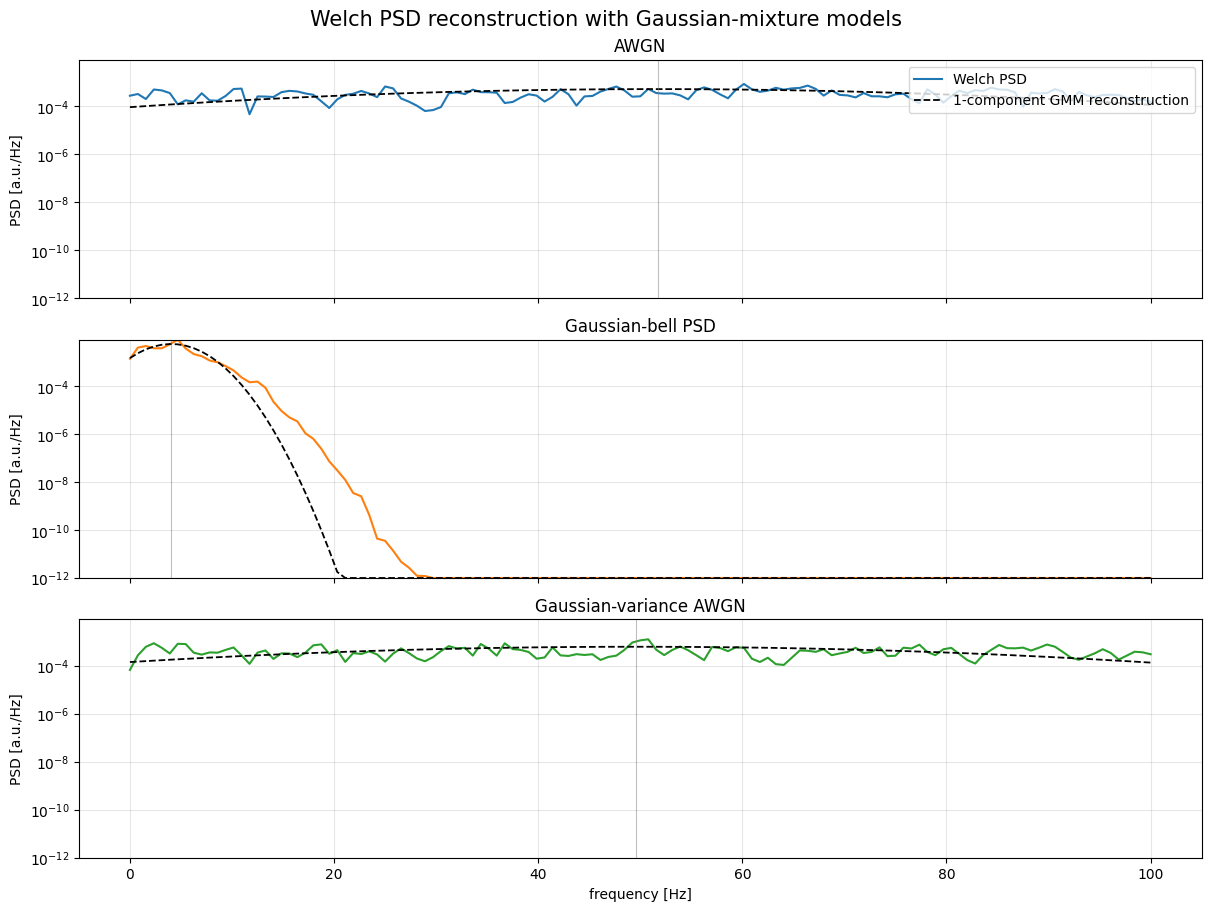

GMM components per model = 1
AWGN: rmse=0.000183, means_hz=[51.7], std_hz=[27.76]
Gaussian-bell PSD: rmse=0.000420, means_hz=[4.05], std_hz=[2.46]
Gaussian-variance AWGN: rmse=0.000263, means_hz=[49.56], std_hz=[28.91]


In [20]:
row_colors = ["tab:blue", "tab:orange", "tab:green"]
gmm_rows = []
for (model_name, noise_t), color in zip(noise_models, row_colors, strict=True):
    frequency_hz, psd = estimate_welch_psd(noise_t, sample_rate_hz=sample_rate_hz)
    reconstruction = reconstruct_psd_with_gmm(
        frequency_hz=frequency_hz,
        psd=psd,
        num_components=gmm_components,
    )
    gmm_rows.append(
        {
            "model_name": model_name,
            "color": color,
            "frequency_hz": frequency_hz,
            "psd": np.maximum(psd, 1e-12),
            **reconstruction,
        }
    )

global_gmm_psd_min = min(
    float(np.min(np.minimum(row["psd"], np.maximum(row["reconstructed_psd"], 1e-12))))
    for row in gmm_rows
)
global_gmm_psd_max = max(
    float(np.max(np.maximum(row["psd"], np.maximum(row["reconstructed_psd"], 1e-12))))
    for row in gmm_rows
)
global_gmm_psd_max = max(global_gmm_psd_max, global_gmm_psd_min * 10.0)

figure, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
for row_index, row in enumerate(gmm_rows):
    axes[row_index].semilogy(
        row["frequency_hz"],
        row["psd"],
        color=row["color"],
        linewidth=1.5,
        label="Welch PSD",
    )
    axes[row_index].semilogy(
        row["frequency_hz"],
        np.maximum(row["reconstructed_psd"], 1e-12),
        color="black",
        linestyle="--",
        linewidth=1.3,
        label=f"{gmm_components}-component GMM reconstruction",
    )
    for weight, mean_hz in zip(row["mixing_weights"], row["means_hz"], strict=True):
        axes[row_index].axvline(
            mean_hz,
            color="gray",
            linewidth=0.8,
            alpha=0.15 + 0.35 * float(weight),
        )
    axes[row_index].set_ylim(global_gmm_psd_min, global_gmm_psd_max)
    axes[row_index].set_ylabel("PSD [a.u./Hz]")
    axes[row_index].set_title(row["model_name"])
    axes[row_index].grid(alpha=0.3)
    if row_index == 0:
        axes[row_index].legend(loc="upper right")

axes[-1].set_xlabel("frequency [Hz]")
figure.suptitle("Welch PSD reconstruction with Gaussian-mixture models", fontsize=15)
plt.show()

print(f"GMM components per model = {gmm_components}")
for row in gmm_rows:
    component_std_hz = np.sqrt(row["variances_hz2"])
    means_text = np.array2string(row["means_hz"], precision=2, separator=", ")
    stds_text = np.array2string(component_std_hz, precision=2, separator=", ")
    print(
        f"{row['model_name']}: rmse={row['rmse']:.6f}, "
        f"means_hz={means_text}, std_hz={stds_text}"
    )
